# NPH Batch Analysis

This notebook loads all `T=*` folders under `results/20260305_NPH`, filters rows to `phase == 'NPH'`, merges `observables.csv` with `triangulation_stats.csv` on the shared per-frame keys, and makes the requested histograms and scatter plots. No `NVT` rows are used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_REL = Path('results/20260305_NPH')
PLOT_DIRNAME = 'data_analysis'


def locate_results_root(target_rel=RESULTS_REL):
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        candidate = parent / target_rel
        if candidate.exists():
            return candidate
    raise RuntimeError(f'Could not find {target_rel} starting from {cwd}')


def load_temperature_frame(temp_dir):
    obs_path = temp_dir / 'sample_csv' / 'observables.csv'
    tri_path = temp_dir / 'sample_csv' / 'triangulation_stats.csv'

    obs = pd.read_csv(obs_path)
    tri = pd.read_csv(tri_path)

    obs = obs[obs['phase'].eq('NPH')].copy()
    tri = tri[tri['phase'].eq('NPH')].copy()

    if obs.empty or tri.empty:
        raise RuntimeError(f'No NPH rows found under {temp_dir}')

    temperature = float(temp_dir.name.split('=')[1])
    obs['temperature'] = temperature
    tri['temperature'] = temperature

    merge_keys = ['temperature', 'global_step', 'phase']
    merged = obs.merge(tri, on=merge_keys, how='inner', validate='one_to_one')
    if merged.empty:
        raise RuntimeError(f'No merged NPH rows found under {temp_dir}')

    merged['AAA_count_plus_BBB_count'] = merged['AAA_count'] + merged['BBB_count']
    merged['AAB_count_plus_ABB_count'] = merged['AAB_count'] + merged['ABB_count']
    merged['AAA_area_plus_BBB_area'] = merged['AAA_area'] + merged['BBB_area']
    merged['AAB_area_plus_ABB_area'] = merged['AAB_area'] + merged['ABB_area']

    # Derived products requested for scatter plots.
    merged['P_box_motion_k'] = merged['P'] * merged['box_motion_K']
    if 'box_motion' in merged.columns:
        merged['P_box_motion'] = merged['P'] * merged['box_motion']
    else:
        merged['P_box_motion'] = merged['P_box_motion_k']

    return merged.sort_values('global_step').reset_index(drop=True)


results_root = locate_results_root()
output_dir = results_root / PLOT_DIRNAME
output_dir.mkdir(exist_ok=True)

temp_dirs = sorted(
    results_root.glob('T=*'),
    key=lambda path: float(path.name.split('=')[1]),
)
frames = [load_temperature_frame(temp_dir) for temp_dir in temp_dirs]
merged = pd.concat(frames, ignore_index=True)
merged = merged.sort_values(['temperature', 'global_step']).reset_index(drop=True)

summary = (
    merged.groupby('temperature')
    .agg(
        n_frames=('global_step', 'size'),
        first_step=('global_step', 'min'),
        last_step=('global_step', 'max'),
        mean_volume=('volume', 'mean'),
        mean_pressure=('P', 'mean'),
    )
    .reset_index()
)

temperatures = summary['temperature'].tolist()
temp_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(temperatures)))
temp_to_color = {temp: color for temp, color in zip(temperatures, temp_colors)}

print(f'Using results_root = {results_root}')
print(summary.to_string(index=False))
summary


Using results_root = /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH
 temperature  n_frames  first_step  last_step  mean_volume  mean_pressure
         0.5       330      110000    3400000 93622.600921       0.206388
         0.6       329      110000    3390000 93622.690352       0.529966
         0.7       329      110000    3390000 93622.782992       0.864007
         0.8       330      110000    3400000 93622.872989       1.182431
         0.9       329      110000    3390000 93622.957727       1.492893
         1.0       329      110000    3390000 93623.040550       1.787690


,temperature,n_frames,first_step,last_step,mean_volume,mean_pressure
0,0.5,330,110000,3400000,93622.600921,0.206388
1,0.6,329,110000,3390000,93622.690352,0.529966
2,0.7,329,110000,3390000,93622.782992,0.864007
3,0.8,330,110000,3400000,93622.872989,1.182431
4,0.9,329,110000,3390000,93622.957727,1.492893
5,1.0,329,110000,3390000,93623.040550,1.787690


Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_box_motion_K.png


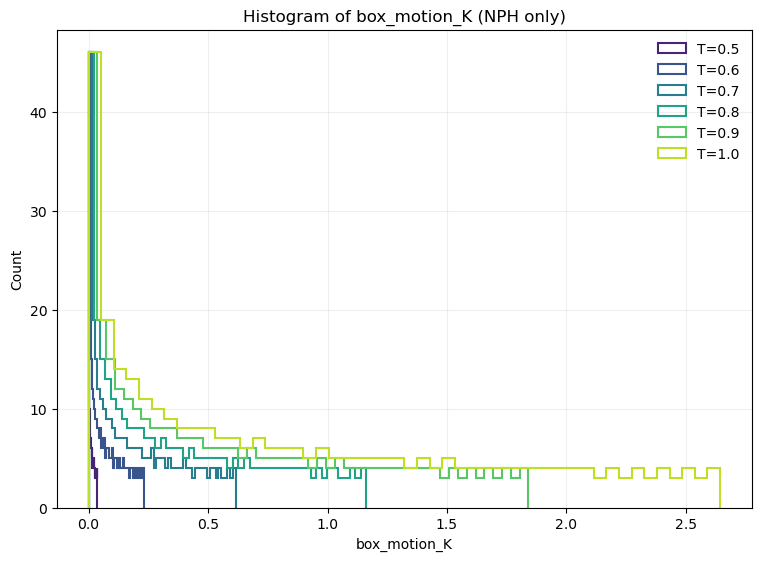

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_U_tot.png


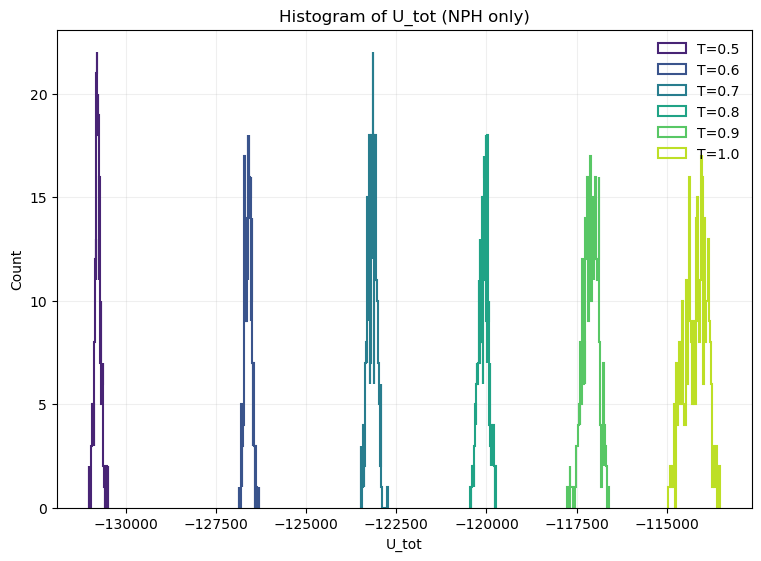

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_P.png


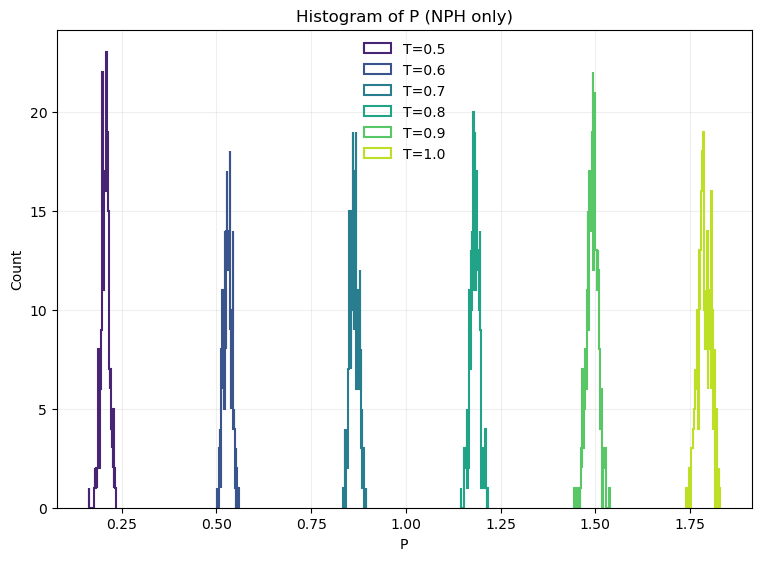

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_volume.png


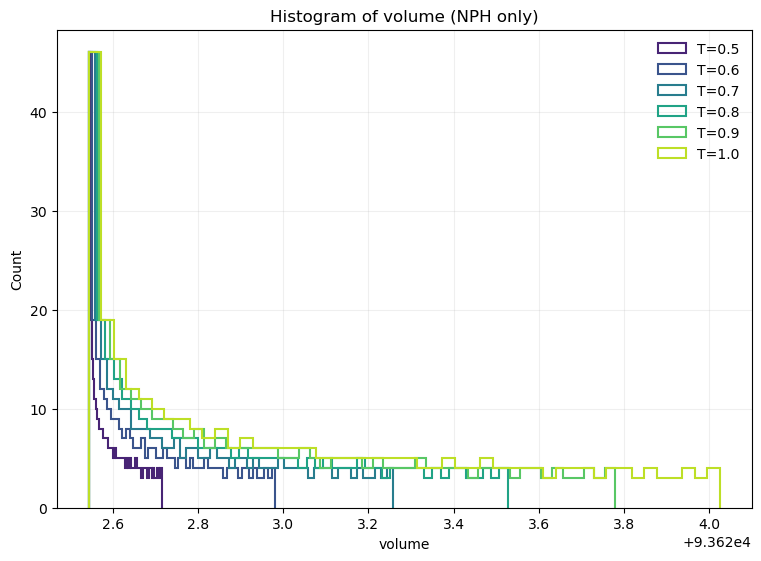

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_L_tot.png


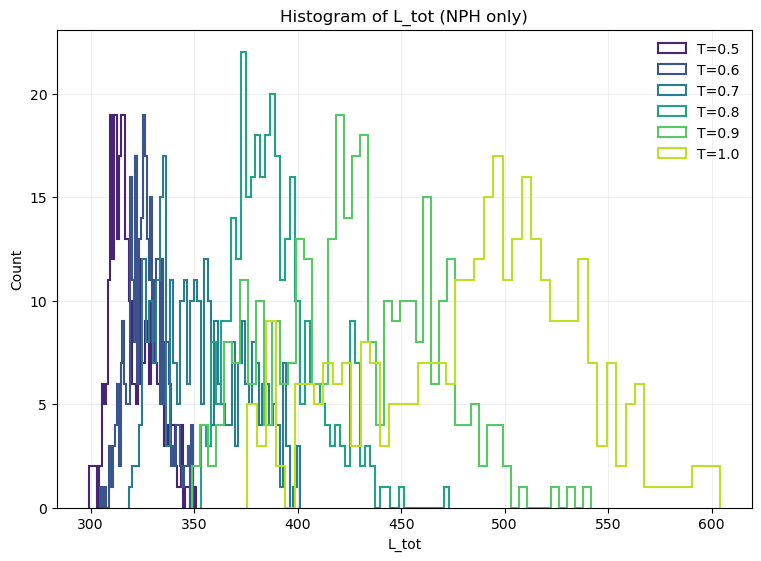

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_AB_pair_length.png


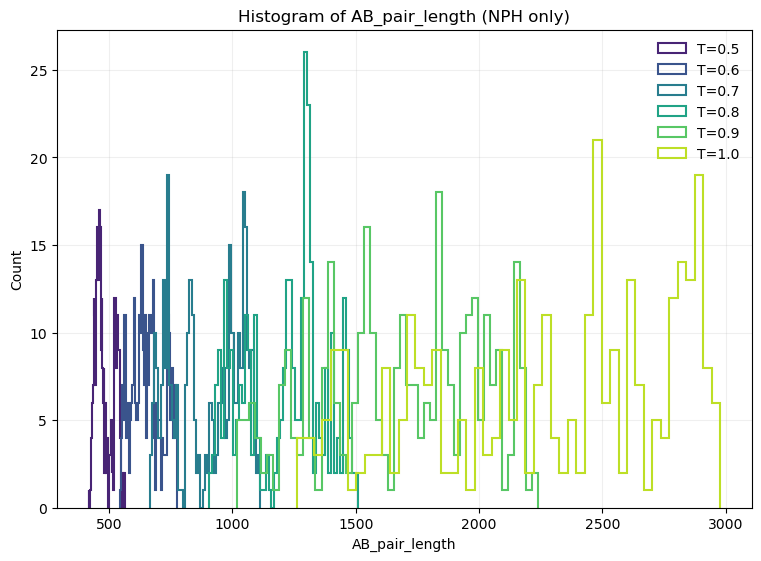

In [2]:
hist_specs = [
    ('box_motion_K', 'box_motion_K'),
    ('U_tot', 'U_tot'),
    ('P', 'P'),
    ('volume', 'volume'),
    ('L_tot', 'L_tot'),
    ('AB_pair_length', 'AB_pair_length'),
]

for column, title in hist_specs:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)

    for temp in temperatures:
        temp_values = pd.to_numeric(
            merged.loc[merged['temperature'].eq(temp), column],
            errors='coerce',
        ).dropna()
        if temp_values.empty:
            continue
        ax.hist(
            temp_values,
            bins=50,
            histtype='step',
            linewidth=1.5,
            color=temp_to_color[temp],
            label=f'T={temp:.1f}',
        )

    ax.set_title(f'Histogram of {title} (NPH only)')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

    hist_path = output_dir / f'nph_histogram_{column}.png'
    fig.savefig(hist_path, dpi=200, bbox_inches='tight')
    print(f'Saved {hist_path}')
    plt.show(block=False)
    plt.close(fig)


Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_ab_pair_length_vs_aaa_count_plus_bbb_count.png


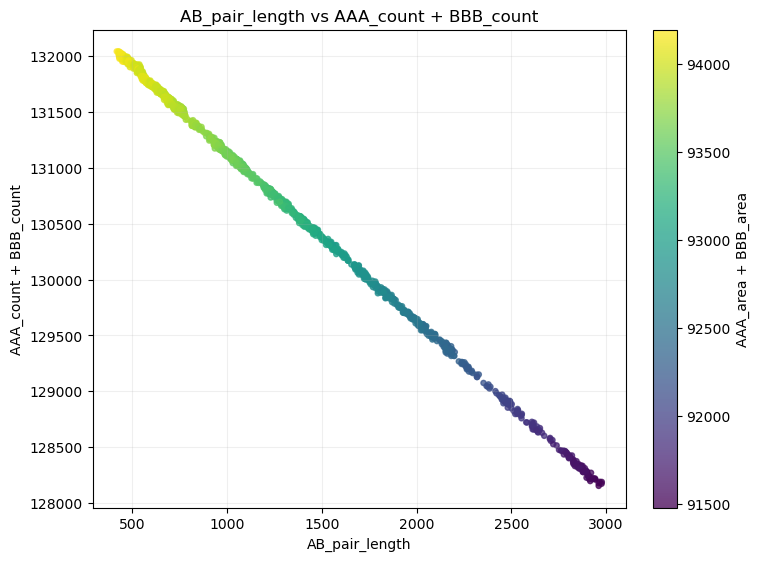

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_aab_count_plus_abb_count_vs_aab_area_plus_abb_area.png


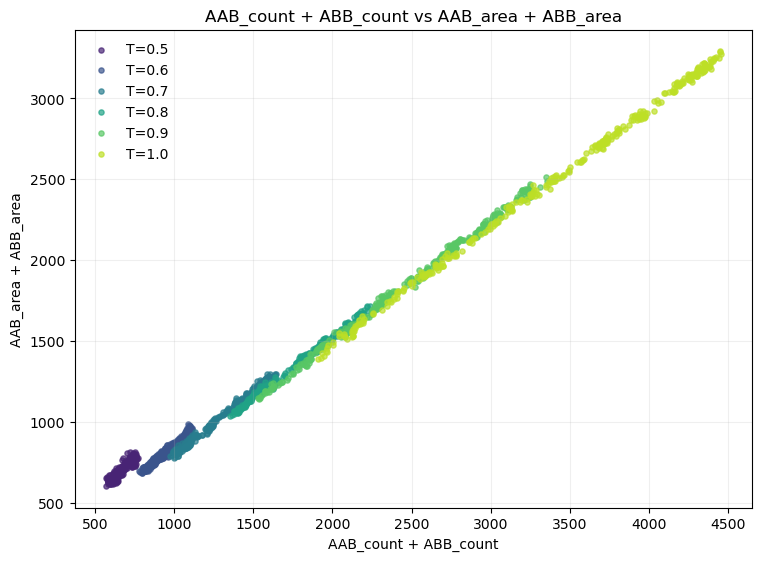

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_aab_count_plus_abb_count_vs_aaa_area_plus_bbb_area.png


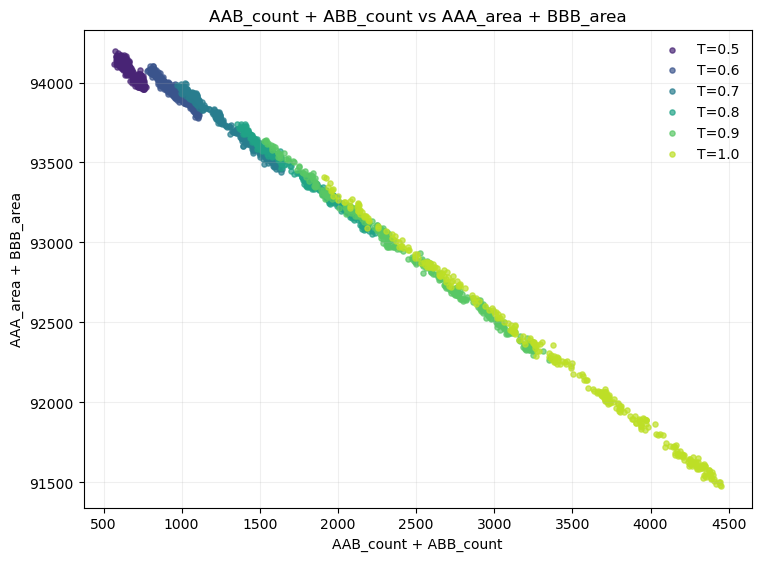

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_ab_pair_length_vs_volume_colored_by_temperature.png


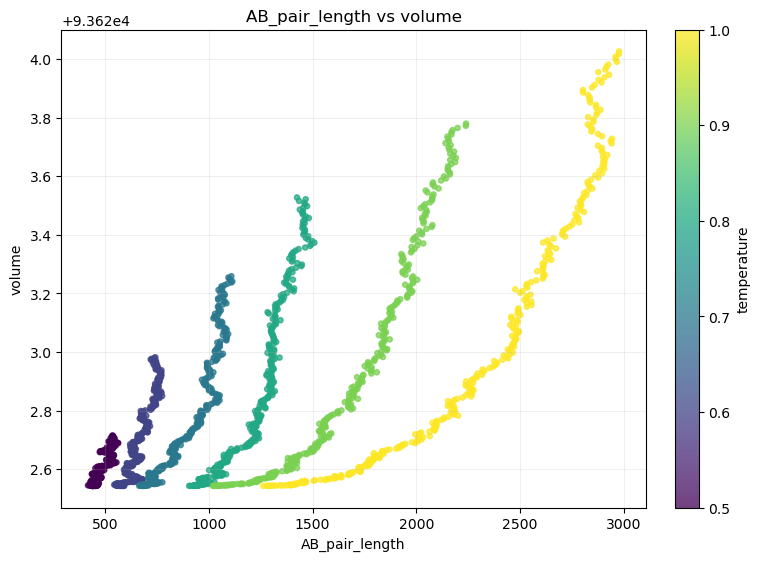

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_p_box_motion_k_vs_volume.png


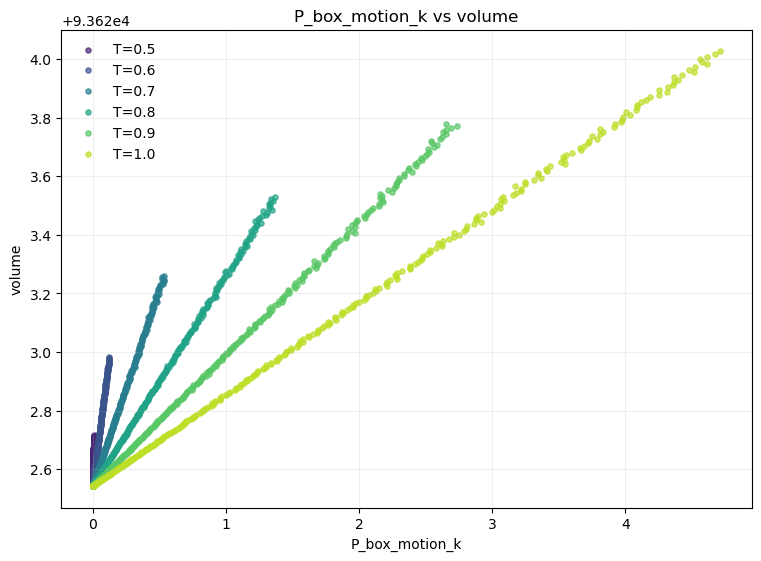

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_p_box_motion_vs_aaa_area_plus_bbb_area.png


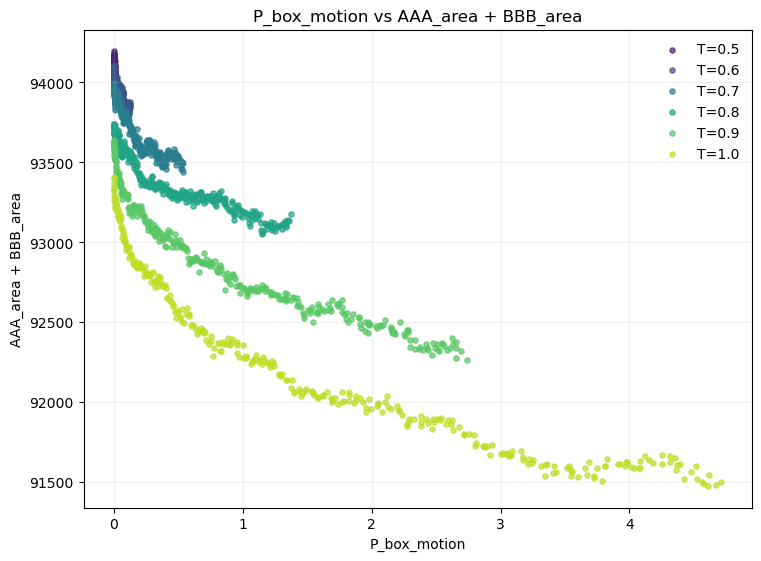

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_ab_pair_length_vs_p_box_motion.png


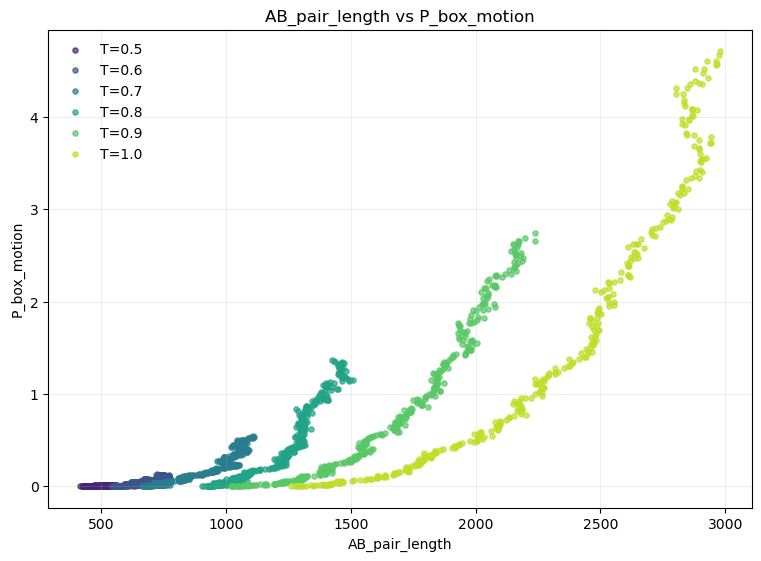

In [3]:
def scatter_with_colorbar(x_col, y_col, c_col, title, x_label, y_label, c_label, filename):
    plot_df = merged[[x_col, y_col, c_col]].apply(pd.to_numeric, errors='coerce').dropna()
    fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
    scatter = ax.scatter(
        plot_df[x_col],
        plot_df[y_col],
        c=plot_df[c_col],
        cmap='viridis',
        s=14,
        alpha=0.75,
    )
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.2)
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label(c_label)

    scatter_path = output_dir / filename
    fig.savefig(scatter_path, dpi=200, bbox_inches='tight')
    print(f'Saved {scatter_path}')
    plt.show(block=False)
    plt.close(fig)


def scatter_by_temperature(x_col, y_col, title, x_label, y_label, filename):
    fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)

    for temp in temperatures:
        temp_df = merged.loc[merged['temperature'].eq(temp), [x_col, y_col]].apply(
            pd.to_numeric,
            errors='coerce',
        ).dropna()
        if temp_df.empty:
            continue
        ax.scatter(
            temp_df[x_col],
            temp_df[y_col],
            s=14,
            alpha=0.7,
            color=temp_to_color[temp],
            label=f'T={temp:.1f}',
        )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

    scatter_path = output_dir / filename
    fig.savefig(scatter_path, dpi=200, bbox_inches='tight')
    print(f'Saved {scatter_path}')
    plt.show(block=False)
    plt.close(fig)


# Existing scatter plots, now as one figure per plot.
scatter_with_colorbar(
    x_col='AB_pair_length',
    y_col='AAA_count_plus_BBB_count',
    c_col='AAA_area_plus_BBB_area',
    title='AB_pair_length vs AAA_count + BBB_count',
    x_label='AB_pair_length',
    y_label='AAA_count + BBB_count',
    c_label='AAA_area + BBB_area',
    filename='nph_scatter_ab_pair_length_vs_aaa_count_plus_bbb_count.png',
)

scatter_by_temperature(
    x_col='AAB_count_plus_ABB_count',
    y_col='AAB_area_plus_ABB_area',
    title='AAB_count + ABB_count vs AAB_area + ABB_area',
    x_label='AAB_count + ABB_count',
    y_label='AAB_area + ABB_area',
    filename='nph_scatter_aab_count_plus_abb_count_vs_aab_area_plus_abb_area.png',
)

scatter_by_temperature(
    x_col='AAB_count_plus_ABB_count',
    y_col='AAA_area_plus_BBB_area',
    title='AAB_count + ABB_count vs AAA_area + BBB_area',
    x_label='AAB_count + ABB_count',
    y_label='AAA_area + BBB_area',
    filename='nph_scatter_aab_count_plus_abb_count_vs_aaa_area_plus_bbb_area.png',
)

# Newly requested scatter plots.
scatter_with_colorbar(
    x_col='AB_pair_length',
    y_col='volume',
    c_col='temperature',
    title='AB_pair_length vs volume',
    x_label='AB_pair_length',
    y_label='volume',
    c_label='temperature',
    filename='nph_scatter_ab_pair_length_vs_volume_colored_by_temperature.png',
)

scatter_by_temperature(
    x_col='P_box_motion_k',
    y_col='volume',
    title='P_box_motion_k vs volume',
    x_label='P_box_motion_k',
    y_label='volume',
    filename='nph_scatter_p_box_motion_k_vs_volume.png',
)

scatter_by_temperature(
    x_col='P_box_motion',
    y_col='AAA_area_plus_BBB_area',
    title='P_box_motion vs AAA_area + BBB_area',
    x_label='P_box_motion',
    y_label='AAA_area + BBB_area',
    filename='nph_scatter_p_box_motion_vs_aaa_area_plus_bbb_area.png',
)

scatter_by_temperature(
    x_col='AB_pair_length',
    y_col='P_box_motion',
    title='AB_pair_length vs P_box_motion',
    x_label='AB_pair_length',
    y_label='P_box_motion',
    filename='nph_scatter_ab_pair_length_vs_p_box_motion.png',
)


## Additional Histogram and Scatter Ideas

These extra plots focus on: (1) equation-of-state style behavior (`P` vs `volume` and `P*V`), (2) triangle-type ordering balance, and (3) energy partitioning (`U_tot` vs `K_tot`).


Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_PV.png


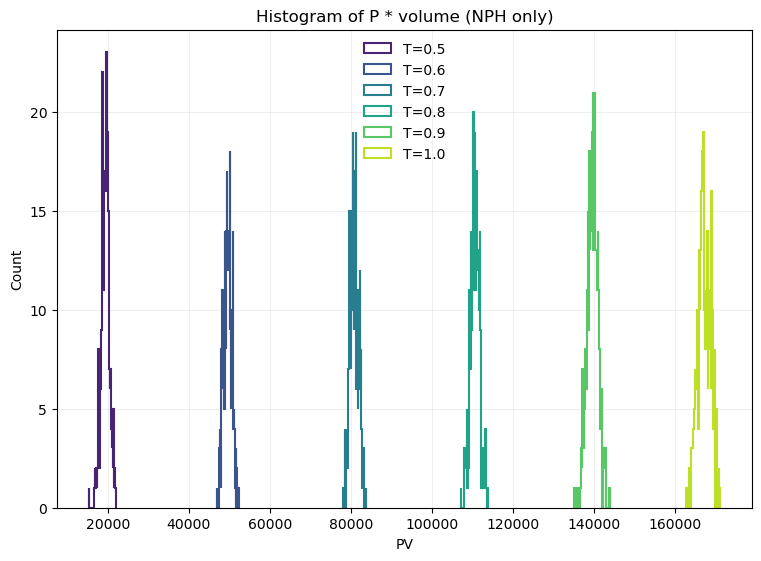

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_tri_order_parameter.png


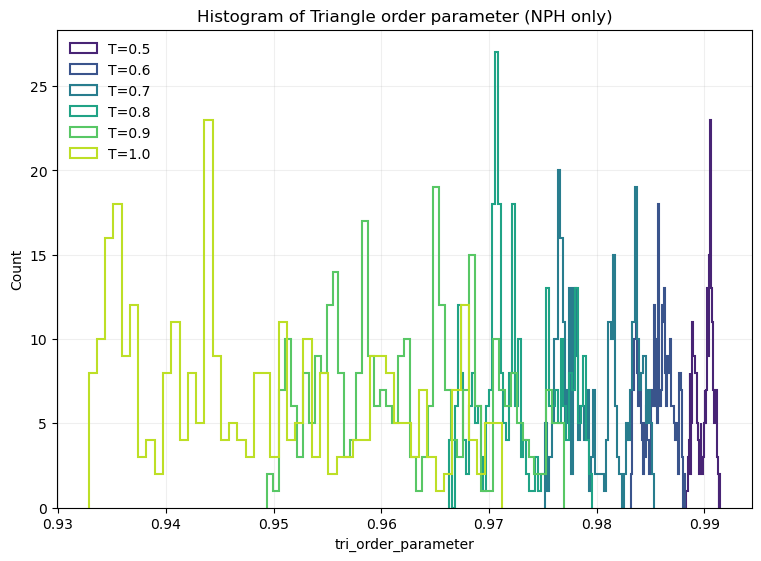

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_histogram_same_type_area_fraction.png


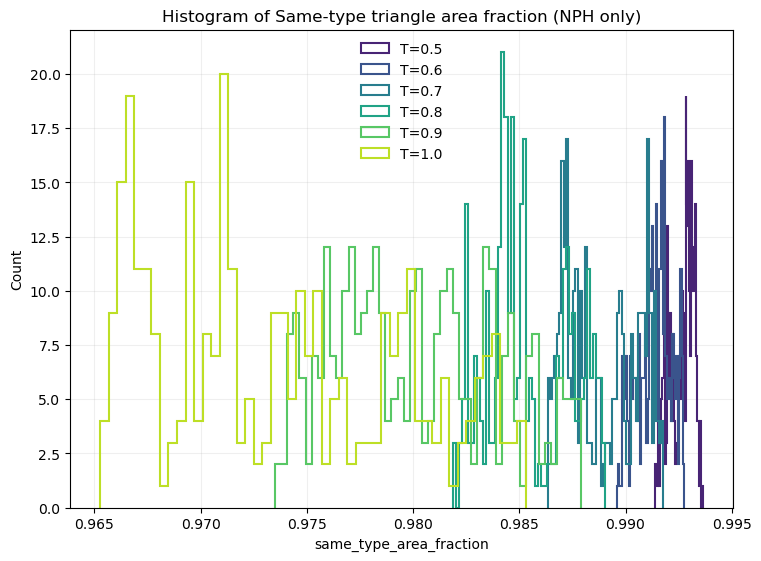

In [4]:
# Additional derived observables for exploratory histograms.
merged['PV'] = pd.to_numeric(merged['P'], errors='coerce') * pd.to_numeric(merged['volume'], errors='coerce')

tri_total_count = (
    pd.to_numeric(merged['AAA_count_plus_BBB_count'], errors='coerce')
    + pd.to_numeric(merged['AAB_count_plus_ABB_count'], errors='coerce')
)
merged['tri_order_parameter'] = (
    pd.to_numeric(merged['AAA_count_plus_BBB_count'], errors='coerce')
    - pd.to_numeric(merged['AAB_count_plus_ABB_count'], errors='coerce')
) / tri_total_count.replace(0, np.nan)

total_tri_area = (
    pd.to_numeric(merged['AAA_area_plus_BBB_area'], errors='coerce')
    + pd.to_numeric(merged['AAB_area_plus_ABB_area'], errors='coerce')
)
merged['same_type_area_fraction'] = (
    pd.to_numeric(merged['AAA_area_plus_BBB_area'], errors='coerce')
    / total_tri_area.replace(0, np.nan)
)

extra_hist_specs = [
    ('PV', 'P * volume'),
    ('tri_order_parameter', 'Triangle order parameter'),
    ('same_type_area_fraction', 'Same-type triangle area fraction'),
]

for column, title in extra_hist_specs:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)

    for temp in temperatures:
        temp_values = pd.to_numeric(
            merged.loc[merged['temperature'].eq(temp), column],
            errors='coerce',
        ).dropna()
        if temp_values.empty:
            continue
        ax.hist(
            temp_values,
            bins=50,
            histtype='step',
            linewidth=1.5,
            color=temp_to_color[temp],
            label=f'T={temp:.1f}',
        )

    ax.set_title(f'Histogram of {title} (NPH only)')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

    hist_path = output_dir / f'nph_histogram_{column}.png'
    fig.savefig(hist_path, dpi=200, bbox_inches='tight')
    print(f'Saved {hist_path}')
    plt.show(block=False)
    plt.close(fig)


Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_pressure_vs_volume_colored_by_temperature.png


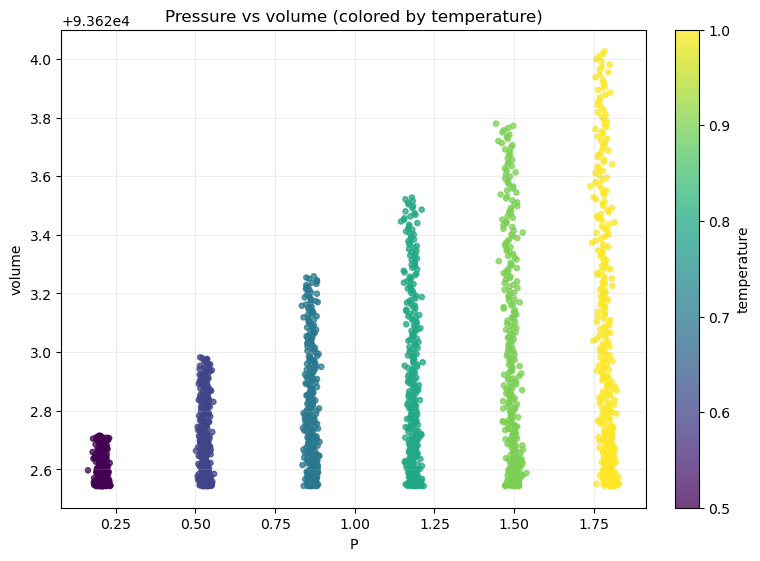

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_tri_order_parameter_vs_ab_pair_length.png


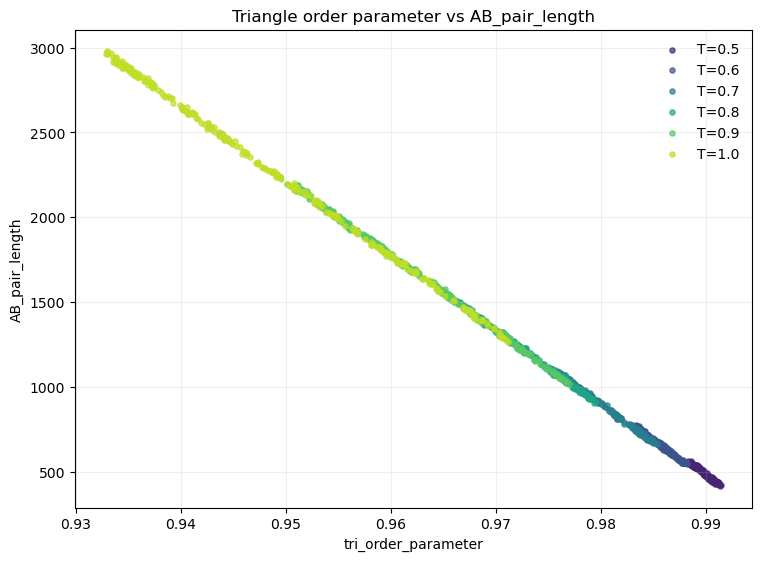

Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_scatter_u_tot_vs_k_tot_colored_by_tri_order_parameter.png


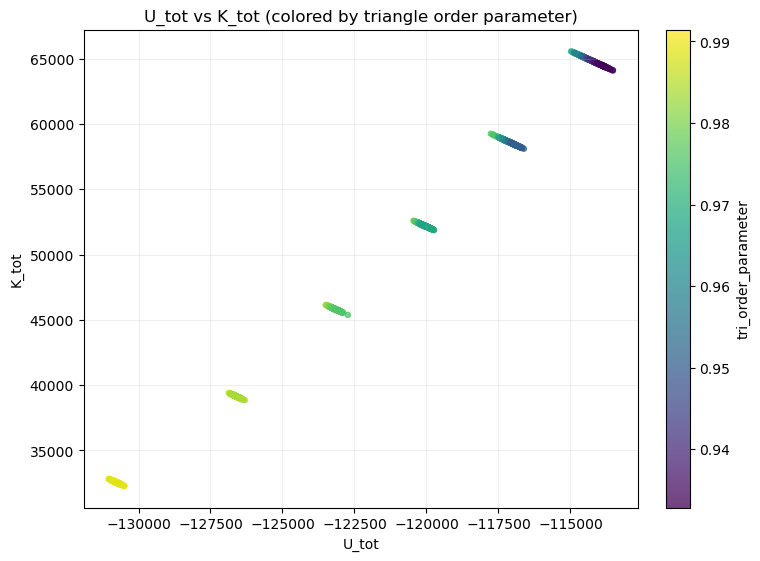

In [5]:
# Additional scatter diagnostics.
scatter_with_colorbar(
    x_col='P',
    y_col='volume',
    c_col='temperature',
    title='Pressure vs volume (colored by temperature)',
    x_label='P',
    y_label='volume',
    c_label='temperature',
    filename='nph_scatter_pressure_vs_volume_colored_by_temperature.png',
)

scatter_by_temperature(
    x_col='tri_order_parameter',
    y_col='AB_pair_length',
    title='Triangle order parameter vs AB_pair_length',
    x_label='tri_order_parameter',
    y_label='AB_pair_length',
    filename='nph_scatter_tri_order_parameter_vs_ab_pair_length.png',
)

scatter_with_colorbar(
    x_col='U_tot',
    y_col='K_tot',
    c_col='tri_order_parameter',
    title='U_tot vs K_tot (colored by triangle order parameter)',
    x_label='U_tot',
    y_label='K_tot',
    c_label='tri_order_parameter',
    filename='nph_scatter_u_tot_vs_k_tot_colored_by_tri_order_parameter.png',
)


Per-temperature regression summary:
 temperature  n_points    slope  intercept  r_squared
         0.5       330 0.911287  95.538749   0.850254
         0.6       329 0.833919  28.067565   0.963143
         0.7       329 0.777041  24.870967   0.991494
         0.8       330 0.751003  23.633502   0.994160
         0.9       329 0.746585   9.305609   0.997358
         1.0       329 0.730934  18.023543   0.998949


Saved /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260305_NPH/data_analysis/nph_slope_aab_area_plus_abb_area_vs_aab_count_plus_abb_count.png


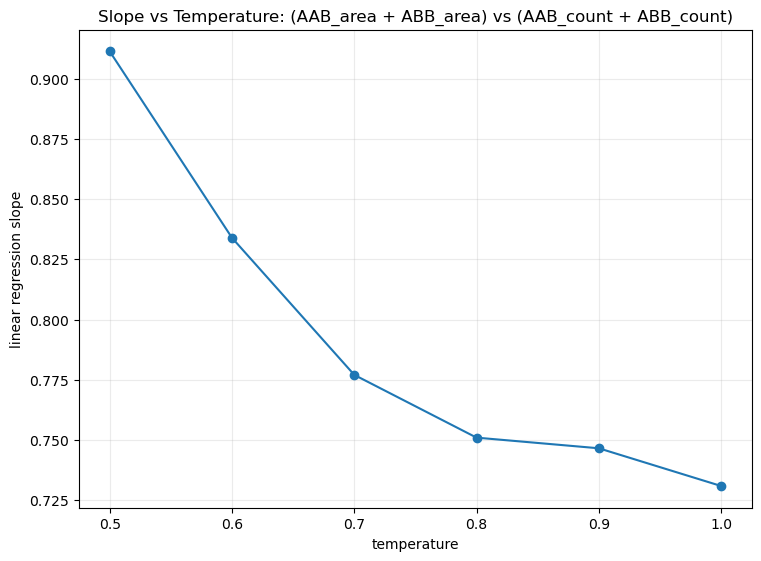

In [6]:
# Linear regression: (AAB_area + ABB_area) vs (AAB_count + ABB_count) for each temperature.
regression_rows = []

for temp in temperatures:
    temp_df = merged.loc[
        merged['temperature'].eq(temp),
        ['AAB_count_plus_ABB_count', 'AAB_area_plus_ABB_area'],
    ].apply(pd.to_numeric, errors='coerce').dropna()

    if len(temp_df) < 2:
        continue

    x = temp_df['AAB_count_plus_ABB_count'].to_numpy()
    y = temp_df['AAB_area_plus_ABB_area'].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = np.nan if ss_tot == 0 else (1 - ss_res / ss_tot)

    regression_rows.append(
        {
            'temperature': temp,
            'n_points': len(temp_df),
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_squared,
        }
    )

regression_df = pd.DataFrame(regression_rows).sort_values('temperature').reset_index(drop=True)

if regression_df.empty:
    raise RuntimeError('No valid per-temperature data for regression.')

print('Per-temperature regression summary:')
print(regression_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
ax.plot(
    regression_df['temperature'],
    regression_df['slope'],
    marker='o',
    linewidth=1.5,
    color='tab:blue',
)
ax.set_title('Slope vs Temperature: (AAB_area + ABB_area) vs (AAB_count + ABB_count)')
ax.set_xlabel('temperature')
ax.set_ylabel('linear regression slope')
ax.grid(alpha=0.25)

slope_plot_path = output_dir / 'nph_slope_aab_area_plus_abb_area_vs_aab_count_plus_abb_count.png'
fig.savefig(slope_plot_path, dpi=200, bbox_inches='tight')
print(f'Saved {slope_plot_path}')
plt.show(block=False)
plt.close(fig)
